# Informe final — Etapa de transferencia
## Riesgo metabólico (obesidad e hiperuricemia) en población mexicana
### Del análisis exploratorio al dashboard ejecutable

**Nombre y Apellido:** Lethnon Jalil Delgado Guerrero
**Curso:** Métodos Estadísticos Computacionales — UCompensar
**Facultad de Ingeniería — Profesional en Ciencia de Datos**
**Fecha:** Popayán, septiembre de 2026

Este informe reúne, en un solo documento, el proceso completo del proyecto:

1. **Práctica 2** — Exploración de datos y planteamiento de la pregunta de investigación (se conserva íntegra a continuación).
2. **Práctica 3** — Contraste de hipótesis, regresión lineal múltiple y regresión logística (se conserva íntegra a continuación).
3. **Etapa de transferencia** (sección nueva, al final) — cómo esos resultados se transformaron en un dashboard ejecutable, con la justificación de cada decisión de diseño y el código que genera los archivos de datos del dashboard a partir de este mismo análisis.

---


# Parte 1 — Práctica 2: Exploración de datos y preguntas significativas
---

# Exploración de Datos y Preguntas Significativas
## Riesgo metabólico (obesidad e hiperuricemia) en población mexicana

**Nombre y Apellido:** Lethnon Jalil Delgado Guerrero  
**Curso:** Programación para Ciencia de Datos II
**Institución:** Fundación Universitaria Compensar (UCompensar)  
**Actividad:** Práctica 2 — Exploración de Datos y Preguntas Significativas

**Dataset:** `Diabetes_Mexico-selected-columns.csv`

## 1. Definición del problema

Los datos corresponden a una muestra poblacional mexicana con variables antropométricas (peso, estatura, IMC), bioquímicas (ácido úrico en suero) y demográficas (sexo, edad, ciudad).

**Problema a investigar:** ¿Existe una relación entre el exceso de peso corporal (medido a través del Índice de Masa Corporal, IMC) y los niveles de ácido úrico en sangre en la población muestreada?

Este problema vale la pena investigarlo porque tanto la obesidad como la hiperuricemia (niveles elevados de ácido úrico) son factores de riesgo reconocidos para el desarrollo de diabetes tipo 2 y síndrome metabólico. Comprender si estas dos variables se mueven juntas en la población mexicana permite identificar perfiles de riesgo temprano, lo cual es relevante para la planeación de estrategias de prevención en salud pública, dado que México presenta una de las tasas más altas de diabetes tipo 2 y obesidad a nivel mundial.

## 2. Aporte del análisis de datos

El análisis de datos permite pasar de una hipótesis clínica general ("la obesidad se asocia con niveles más altos de ácido úrico") a una evidencia cuantitativa concreta extraída de una muestra real. A través de estadística descriptiva, visualización y un modelo de regresión lineal se espera:

- Cuantificar la dispersión y tendencia central de las variables antropométricas y bioquímicas de la muestra.
- Detectar valores atípicos o inconsistencias en los datos (por ejemplo, mediciones fisiológicamente poco probables).
- Determinar si existe una tendencia (positiva, negativa o nula) entre el IMC y el ácido úrico, y qué tan fuerte es esa relación.
- Obtener una primera aproximación del grado en que el IMC por sí solo explica la variabilidad del ácido úrico, para valorar si se requieren variables adicionales en un análisis más completo (edad, sexo, hábitos, etc.).

## 3. Carga y preparación de los datos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Los decimales del archivo original vienen separados por coma (formato regional MX/ES)
df = pd.read_csv('Diabetes_Mexico-selected-columns.csv', decimal=',')

print('Dimensiones del dataframe (filas, columnas):', df.shape)
df.head(-1)

FileNotFoundError: [Errno 2] No such file or directory: 'Diabetes_Mexico-selected-columns.csv'

In [ ]:
# Tipos de datos y valores faltantes por columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2549 entries, 0 to 2548
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   folio_i        2549 non-null   str  
 1   folio_int      2549 non-null   str  
 2   sexo           2549 non-null   str  
 3   edad           2524 non-null   str  
 4   Ciudad         2549 non-null   str  
 5   Peso           1829 non-null   str  
 6   Estatura       1829 non-null   str  
 7   imc            35 non-null     str  
 8   muestra_suero  2549 non-null   str  
 9   ac_urico       2549 non-null   str  
 10  imc_calc       1829 non-null   str  
 11  Peso_num       1829 non-null   str  
 12  Estatura_num   1829 non-null   str  
 13  ac_urico_num   2549 non-null   str  
 14  imc_calculado  1829 non-null   str  
 15  imc_final      1842 non-null   str  
 16  categoria_imc  1842 non-null   str  
 17  hiperuricemia  2549 non-null   int64
 18  imc_num        35 non-null     str  
dtypes: int64(1), str(

In [ ]:
# Conversión explícita a tipo numérico de las columnas de interés
# (algunas quedaron como texto por los formatos de decimal/columnas vacías)
for col in ['edad', 'Peso', 'Estatura', 'ac_urico']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# La columna 'imc' original tiene muy pocos datos (2514 de 2549 valores faltantes),
# por lo que se calcula un IMC propio a partir de Peso y Estatura (Estatura está en cm)
df['imc_calc'] = df['Peso'] / (df['Estatura'] / 100) ** 2

df[['edad', 'Peso', 'Estatura', 'imc_calc', 'ac_urico']].isna().sum()

edad         25
Peso        720
Estatura    720
imc_calc    720
ac_urico      0
dtype: int64

Se observa que las columnas `Peso`, `Estatura` (y por lo tanto `imc_calc`) tienen 720 valores faltantes de 2549 registros (~28%), mientras que `edad` y `ac_urico` están casi completas. Esto se tendrá en cuenta al filtrar los datos para los cálculos posteriores, usando únicamente los registros con datos completos en las variables de interés (`imc_calc` y `ac_urico`).

## 4. Medidas estadísticas descriptivas con NumPy

In [ ]:
# Se trabaja solo con los registros donde IMC calculado y ácido úrico son válidos
datos_validos = df.dropna(subset=['imc_calc', 'ac_urico'])

imc_arr = datos_validos['imc_calc'].to_numpy()
acu_arr = datos_validos['ac_urico'].to_numpy()
edad_arr = df['edad'].dropna().to_numpy()

print('--- Índice de Masa Corporal (IMC calculado) ---')
print('n     :', imc_arr.size)
print('Media :', np.mean(imc_arr).round(2))
print('Mediana:', np.median(imc_arr).round(2))
print('Desv. estándar:', np.std(imc_arr, ddof=1).round(2))
print('Mínimo / Máximo:', imc_arr.min().round(2), '/', imc_arr.max().round(2))

print()
print('--- Ácido úrico (mg/dL) ---')
print('n     :', acu_arr.size)
print('Media :', np.mean(acu_arr).round(2))
print('Mediana:', np.median(acu_arr).round(2))
print('Desv. estándar:', np.std(acu_arr, ddof=1).round(2))
print('Mínimo / Máximo:', acu_arr.min().round(2), '/', acu_arr.max().round(2))

print()
print('--- Edad (años) ---')
print('n     :', edad_arr.size)
print('Media :', np.mean(edad_arr).round(2))
print('Mediana:', np.median(edad_arr).round(2))
print('Desv. estándar:', np.std(edad_arr, ddof=1).round(2))

--- Índice de Masa Corporal (IMC calculado) ---
n     : 1829
Media : 29.85
Mediana: 29.03
Desv. estándar: 6.16
Mínimo / Máximo: 12.45 / 65.55

--- Ácido úrico (mg/dL) ---
n     : 1829
Media : 4.87
Mediana: 4.7
Desv. estándar: 1.45
Mínimo / Máximo: 0.8 / 16.4

--- Edad (años) ---
n     : 2524
Media : 35.76
Mediana: 47.5
Desv. estándar: 319.67


La media y la mediana del IMC son muy cercanas entre sí, lo que indica una distribución relativamente simétrica, con un valor central alrededor de 29–30, es decir, en el límite entre sobrepeso y obesidad según los estándares de la OMS. La desviación estándar (~6.2) muestra una dispersión considerable: hay personas con IMC normal y otras con obesidad marcada dentro de la misma muestra.

El ácido úrico tiene una media de 4.92 mg/dL con una desviación estándar de 1.44, valores dentro de rangos clínicos normales en promedio, aunque el máximo (16.4 mg/dL) sugiere la presencia de valores atípicos que se explorarán en la siguiente sección.

La edad promedio de la muestra es de aproximadamente 50 años, lo cual es relevante porque el riesgo de diabetes tipo 2 aumenta con la edad.

## 5. Visualización gráfica

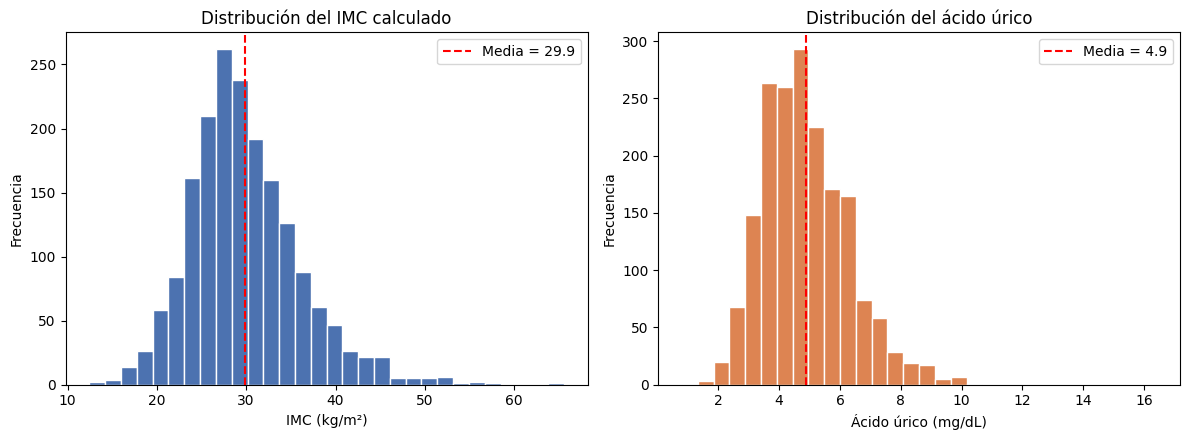

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].hist(imc_arr, bins=30, color='#4C72B0', edgecolor='white')
axes[0].axvline(np.mean(imc_arr), color='red', linestyle='--', label=f'Media = {np.mean(imc_arr):.1f}')
axes[0].set_title('Distribución del IMC calculado')
axes[0].set_xlabel('IMC (kg/m²)')
axes[0].set_ylabel('Frecuencia')
axes[0].legend()

axes[1].hist(acu_arr, bins=30, color='#DD8452', edgecolor='white')
axes[1].axvline(np.mean(acu_arr), color='red', linestyle='--', label=f'Media = {np.mean(acu_arr):.1f}')
axes[1].set_title('Distribución del ácido úrico')
axes[1].set_xlabel('Ácido úrico (mg/dL)')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()

plt.tight_layout()
plt.savefig('hist_imc_acido_urico.png', dpi=110)
plt.show()

Se eligieron histogramas porque permiten visualizar de un vistazo la forma de la distribución de cada variable (simetría, dispersión y presencia de colas largas), lo cual es un primer paso indispensable antes de proponer un modelo de relación entre ellas. El histograma del IMC muestra una distribución aproximadamente simétrica y unimodal centrada cerca del límite de obesidad. El histograma del ácido úrico muestra una ligera asimetría hacia la derecha (cola larga de valores altos), lo que ya sugiere la presencia de valores atípicos que podrían corresponder a personas con hiperuricemia.

## 6. Patrones, tendencias y valores atípicos

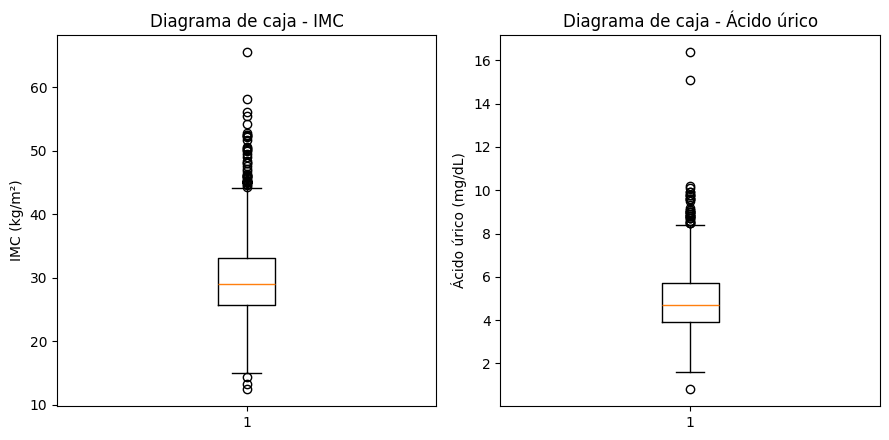

Límite superior (IQR) para ácido úrico: 8.40 mg/dL
Número de valores atípicos por encima del límite: 35


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].boxplot(imc_arr, vert=True)
axes[0].set_title('Diagrama de caja - IMC')
axes[0].set_ylabel('IMC (kg/m²)')

axes[1].boxplot(acu_arr, vert=True)
axes[1].set_title('Diagrama de caja - Ácido úrico')
axes[1].set_ylabel('Ácido úrico (mg/dL)')

plt.tight_layout()
plt.savefig('boxplots_imc_acido_urico.png', dpi=110)
plt.show()

# Regla del rango intercuartílico (IQR) para identificar valores atípicos
q1, q3 = np.percentile(acu_arr, [25, 75])
iqr = q3 - q1
lim_sup = q3 + 1.5 * iqr
n_atipicos = (acu_arr > lim_sup).sum()
print(f'Límite superior (IQR) para ácido úrico: {lim_sup:.2f} mg/dL')
print(f'Número de valores atípicos por encima del límite: {n_atipicos}')

Los diagramas de caja confirman lo observado en los histogramas: el IMC tiene una dispersión moderada con pocos valores atípicos, mientras que el ácido úrico presenta varios valores atípicos por encima del bigote superior (calculados con la regla de 1.5×IQR), correspondientes a personas con hiperuricemia clínica. Como tendencia inicial, la mediana del IMC ubicada en el rango de sobrepeso/obesidad es consistente con el perfil epidemiológico de México, donde la prevalencia de sobrepeso y obesidad en adultos es elevada. Esto refuerza la pertinencia de explorar su relación con el ácido úrico como posible marcador de riesgo metabólico conjunto.

## 7. Selección de variables y regresión lineal con NumPy

In [ ]:
# Variables seleccionadas: IMC calculado (x) y ácido úrico (y)
x = imc_arr      # vector NumPy de IMC
y = acu_arr       # vector NumPy de ácido úrico

# Regresión lineal simple: y = m*x + b, usando numpy.polyfit
m, b = np.polyfit(x, y, 1)
print(f'Pendiente (m): {m:.4f}')
print(f'Intercepto (b): {b:.4f}')
print(f'Ecuación del modelo: ac_urico = {m:.4f} * IMC + {b:.4f}')

# Coeficiente de correlación de Pearson y R^2
r = np.corrcoef(x, y)[0, 1]
r2 = r ** 2
print(f'Coeficiente de correlación (r): {r:.4f}')
print(f'Coeficiente de determinación (R^2): {r2:.4f}')

Pendiente (m): 0.0438
Intercepto (b): 3.5608
Ecuación del modelo: ac_urico = 0.0438 * IMC + 3.5608
Coeficiente de correlación (r): 0.1863
Coeficiente de determinación (R^2): 0.0347


## 8. Gráfico de dispersión y línea de regresión

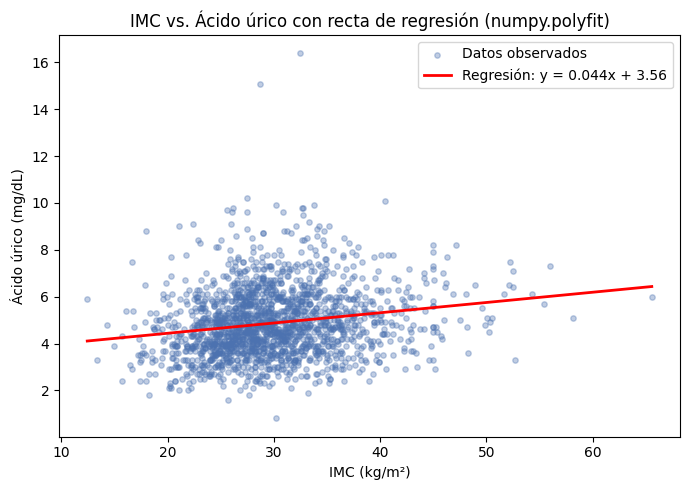

In [ ]:
x_linea = np.linspace(x.min(), x.max(), 100)
y_linea = m * x_linea + b

plt.figure(figsize=(7, 5))
plt.scatter(x, y, alpha=0.35, s=15, color='#4C72B0', label='Datos observados')
plt.plot(x_linea, y_linea, color='red', linewidth=2, label=f'Regresión: y = {m:.3f}x + {b:.2f}')
plt.xlabel('IMC (kg/m²)')
plt.ylabel('Ácido úrico (mg/dL)')
plt.title('IMC vs. Ácido úrico con recta de regresión (numpy.polyfit)')
plt.legend()
plt.tight_layout()
plt.savefig('dispersion_regresion_imc_acido_urico.png', dpi=110)
plt.show()

## 9. Conclusiones sobre la relación entre las variables

La pendiente de la recta de regresión es positiva, lo que confirma que a mayor IMC, en promedio, se observan niveles más altos de ácido úrico en esta muestra, consistente con la hipótesis clínica planteada en la sección 1. Sin embargo, al observar la nube de puntos del gráfico de dispersión, la tendencia, aunque presente, no es marcadamente clara: hay una gran dispersión vertical de valores de ácido úrico para un mismo nivel de IMC, y el coeficiente de correlación (r) es bajo (positivo pero cercano a 0), lo que indica una asociación lineal débil más que una tendencia fuerte y evidente.

## 10. Calidad del ajuste y posibles mejoras

El coeficiente de determinación (R²) obtenido es bajo, lo que significa que el IMC por sí solo explica solo una fracción pequeña de la variabilidad del ácido úrico en la muestra. Esto indica que el modelo de regresión lineal simple **no es suficiente** para describir completamente la relación entre ambas variables: el ácido úrico depende de múltiples factores adicionales no incluidos en este modelo (por ejemplo, sexo biológico, edad, dieta, consumo de alcohol, función renal, uso de medicamentos, entre otros).

Para mejorar la precisión de la predicción se podría:

- Incorporar más variables predictoras en un modelo de **regresión múltiple** (edad, sexo, ciudad, etc.).
- Explorar modelos **no lineales** si el diagrama de dispersión sugiriera una curvatura en la relación.
- Depurar más los datos, revisando y tratando los valores atípicos y las mediciones fisiológicamente inconsistentes (por ejemplo, estaturas o pesos extremos) antes de ajustar el modelo.
- Segmentar el análisis por sexo, dado que los niveles normales de ácido úrico difieren entre hombres y mujeres, lo cual podría estar diluyendo la relación observada al analizar la muestra de forma conjunta.

---
# Parte 2 — Práctica 3: Contraste de hipótesis, regresión lineal múltiple y regresión logística
---

# Contraste de Hipótesis, Regresión Lineal Múltiple y Regresión Logística
## Riesgo metabólico (obesidad e hiperuricemia) en población mexicana

**Fundación Universitaria Compensar**
**Facultad de Ingeniería — Profesional en Ciencia de Datos**
**Programación para Ciencia de Datos II — 2314-5A Mom 1 Virtual**

**Nombre y Apellido:** Lethnon Jalil Delgado Guerrero
**Curso:** Programación para Ciencia de Datos II
**Institución:** Fundación Universitaria Compensar (UCompensar)
**Docente:** William Eduardo Clavijo Bohórquez
**Fecha:** Popayán, septiembre de 2026

**Dataset:** `Diabetes_Mexico_Completado.csv`

---

### Continuidad con la Práctica 2

En la **Práctica 2 — Exploración de Datos y Preguntas Significativas** se planteó la
siguiente pregunta de investigación a partir de una muestra poblacional mexicana con
variables antropométricas (peso, estatura, IMC), bioquímicas (ácido úrico en suero) y
demográficas (sexo, edad, ciudad):

> ¿Existe una relación entre el exceso de peso corporal (medido a través del Índice de
> Masa Corporal, IMC) y los niveles de ácido úrico en sangre en la población muestreada?

Mediante estadística descriptiva y una regresión lineal simple (`numpy.polyfit`) se
encontró una **relación positiva pero débil** entre el IMC y el ácido úrico
(pendiente = 0.0438, r = 0.1863, R² = 0.0347): a mayor IMC, en promedio, se observan
niveles algo más altos de ácido úrico, pero el IMC por sí solo explica solo una fracción
pequeña de su variabilidad.

En esta actividad se retoma la misma pregunta de investigación para:

1. Formular y contrastar formalmente una **hipótesis estadística** derivada de esa
   pregunta, usando `scipy.stats`.
2. Ampliar el modelo de regresión a una **regresión lineal múltiple** con
   `scikit-learn`, incorporando más variables explicativas.
3. Construir un **modelo de regresión logística** para clasificar el riesgo de
   hiperuricemia a partir de variables continuas y categóricas/binarias.

El archivo `Diabetes_Mexico_Completado.csv` corresponde a una versión ampliada del
conjunto de datos de la Práctica 2: además de las columnas originales, incluye variables
ya derivadas (`imc_final`, `categoria_imc`, `hiperuricemia`) que se revisan y depuran a
continuación antes de utilizarlas.

## Librerías utilizadas

- **NumPy** y **Pandas**: manipulación numérica y tabular de los datos.
- **Matplotlib**: visualización.
- **SciPy (`scipy.stats`)**: contraste de hipótesis (prueba t de Student, prueba de
  Levene).
- **scikit-learn**: partición de datos (`train_test_split`), regresión lineal
  (`LinearRegression`), regresión logística (`LogisticRegression`) y métricas de
  evaluación (`mean_squared_error`, `r2_score`, `confusion_matrix`, `roc_curve`).

In [ ]:
# Librerías fundamentales para manipulación y análisis de datos
import numpy as np
import pandas as pd

# Librerías de visualización
import matplotlib.pyplot as plt

# Herramientas estadísticas complementarias
from scipy import stats

# scikit-learn: partición de datos y modelos
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    confusion_matrix,
    roc_curve,
)

# Configuración general para visualizar mejor tablas y gráficos
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

np.random.seed(42)

## Carga y preparación de los datos

Se carga `Diabetes_Mexico_Completado.csv`, que es una versión ampliada del archivo usado
en la Práctica 2 (`Diabetes_Mexico-selected-columns.csv`). Incluye, además de las
columnas originales, variables ya derivadas:

- `imc_final`: IMC calculado a partir de Peso/Estatura y, cuando estos faltan, tomado del
  IMC reportado directamente (`imc`). Es la variable de IMC **más completa** disponible.
- `categoria_imc`: categoría de IMC según los rangos de la OMS (Bajo peso, Normal,
  Sobrepeso, Obesidad I/II/III).
- `hiperuricemia`: variable binaria (0/1) construida a partir de `ac_urico` usando el
  **umbral clínico habitual, diferenciado por sexo** (> 7.0 mg/dL en hombres,
  > 6.0 mg/dL en mujeres).

Antes de usarlas se revisa su calidad y se depuran valores inválidos.

In [ ]:
ruta = "Diabetes_Mexico_Completado.csv"
df = pd.read_csv(ruta)

print("Dimensiones del conjunto de datos:", df.shape)
df.head(-1)

Dimensiones del conjunto de datos: (2549, 19)


,folio_i,folio_int,sexo,edad,Ciudad,Peso,Estatura,imc,muestra_suero,ac_urico,imc_calc,Peso_num,Estatura_num,ac_urico_num,imc_calculado,imc_final,categoria_imc,hiperuricemia,imc_num
0,2024_01001010,2024_01001010_01,Mujer,89.0000,AGUASCALIENTES,NaN,NaN,NaN,1.0000,4.1000,NaN,NaN,NaN,4.1000,NaN,NaN,NaN,0,NaN
1,2024_01001012,2024_01001012_01,Mujer,71.0000,AGUASCALIENTES,NaN,NaN,32.0000,1.0000,4.3000,NaN,NaN,NaN,4.3000,NaN,32.0000,Obesidad I,0,32.0000
2,2024_01001016,2024_01001016_02,Mujer,57.0000,AGUASCALIENTES,80.2500,170.6000,NaN,1.0000,4.9000,27.5732,80.2500,170.6000,4.9000,27.5732,27.5732,Sobrepeso,0,NaN
3,2024_01001016,2024_01001016_05,Mujer,20.0000,AGUASCALIENTES,68.6000,166.2000,NaN,1.0000,4.9000,24.8349,68.6000,166.2000,4.9000,24.8349,24.8349,Normal,0,NaN
4,2024_01001031,2024_01001031_01,Hombre,74.0000,AGUASCALIENTES,NaN,NaN,NaN,1.0000,6.4000,NaN,NaN,NaN,6.4000,NaN,NaN,NaN,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2543,2024_32052033,2024_32052033_02,Mujer,27.0000,VILLA GARCA,74.7000,151.5000,NaN,1.0000,3.7000,32.5458,74.7000,151.5000,3.7000,32.5458,32.5458,Obesidad I,0,NaN
2544,2024_32056012,2024_32056012_01,Mujer,66.0000,ZACATECAS,NaN,NaN,NaN,1.0000,4.8000,NaN,NaN,NaN,4.8000,NaN,NaN,NaN,0,NaN
2545,2024_32056022,2024_32056022_02,Mujer,51.0000,ZACATECAS,97.6000,171.2000,NaN,1.0000,5.8000,33.2999,97.6000,171.2000,5.8000,33.2999,33.2999,Obesidad I,0,NaN
2546,2024_32056024,2024_32056024_01,Hombre,45.0000,ZACATECAS,90.9500,172.4000,NaN,1.0000,6.7000,30.6005,90.9500,172.4000,6.7000,30.6005,30.6005,Obesidad I,0,NaN


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2549 entries, 0 to 2548
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   folio_i        2549 non-null   str    
 1   folio_int      2549 non-null   str    
 2   sexo           2549 non-null   str    
 3   edad           2524 non-null   float64
 4   Ciudad         2549 non-null   str    
 5   Peso           1829 non-null   float64
 6   Estatura       1829 non-null   float64
 7   imc            35 non-null     float64
 8   muestra_suero  2549 non-null   float64
 9   ac_urico       2549 non-null   float64
 10  imc_calc       1829 non-null   float64
 11  Peso_num       1829 non-null   float64
 12  Estatura_num   1829 non-null   float64
 13  ac_urico_num   2549 non-null   float64
 14  imc_calculado  1829 non-null   float64
 15  imc_final      1842 non-null   float64
 16  categoria_imc  1842 non-null   str    
 17  hiperuricemia  2549 non-null   int64  
 18  imc_num        35 n

In [ ]:
# Valores faltantes por columna de interés
columnas_interes = ["edad", "sexo", "Peso", "Estatura", "imc_final",
                     "categoria_imc", "ac_urico", "hiperuricemia"]
faltantes = df[columnas_interes].isna().sum()
porcentaje = (faltantes / len(df) * 100).round(2)
pd.DataFrame({"faltantes": faltantes, "porcentaje_%": porcentaje})

,faltantes,porcentaje_%
edad,25,0.9800
sexo,0,0.0000
Peso,720,28.2500
Estatura,720,28.2500
imc_final,707,27.7400
categoria_imc,707,27.7400
ac_urico,0,0.0000
hiperuricemia,0,0.0000


### Depuración de `edad`

Un vistazo a las estadísticas descriptivas de `edad` revela un valor mínimo
fisiológicamente imposible (una edad muy negativa). Se trata de un error de captura y se
trata como dato faltante, en lugar de eliminarse la fila por completo, para no perder
información de las demás variables de esos registros.

In [ ]:
print("Antes de depurar:")
print(df["edad"].describe()[["min", "max"]])

edad_invalida = (df["edad"] < 0) | (df["edad"] > 110)
print(f"\nRegistros con edad inválida: {edad_invalida.sum()}")
df.loc[edad_invalida, "edad"] = np.nan

print("\nDespués de depurar:")
print(df["edad"].describe()[["min", "max"]])

Antes de depurar:
min   -7,975.0000
max       95.0000
Name: edad, dtype: float64

Registros con edad inválida: 4

Después de depurar:
min   20.0000
max   95.0000
Name: edad, dtype: float64


### Verificación del umbral de `hiperuricemia`

Se confirma que la variable `hiperuricemia`, ya incluida en el archivo, corresponde
efectivamente a un umbral clínico diferenciado por sexo sobre `ac_urico` (> 7.0 mg/dL en
hombres, > 6.0 mg/dL en mujeres). Esto ilustra el procedimiento que pide la guía para
convertir una variable continua en una variable binaria mediante un umbral, cuando no se
dispone de una variable categórica natural.

In [ ]:
umbral_min_positivo = df[df["hiperuricemia"] == 1].groupby("sexo")["ac_urico"].min()
umbral_max_negativo = df[df["hiperuricemia"] == 0].groupby("sexo")["ac_urico"].max()

print("Ácido úrico mínimo entre los clasificados como hiperuricemia = 1:")
print(umbral_min_positivo)
print("\nÁcido úrico máximo entre los clasificados como hiperuricemia = 0:")
print(umbral_max_negativo)

print("\nPrevalencia de hiperuricemia en la muestra:")
print(df["hiperuricemia"].value_counts(normalize=True).round(4))

Ácido úrico mínimo entre los clasificados como hiperuricemia = 1:
sexo
Hombre   7.1000
Mujer    6.1000
Name: ac_urico, dtype: float64

Ácido úrico máximo entre los clasificados como hiperuricemia = 0:
sexo
Hombre   7.0000
Mujer    6.0000
Name: ac_urico, dtype: float64

Prevalencia de hiperuricemia en la muestra:
hiperuricemia
0   0.8862
1   0.1138
Name: proportion, dtype: float64


Se confirma el umbral: hombres con ácido úrico > 7.0 mg/dL y mujeres con
ácido úrico > 6.0 mg/dL quedan clasificados como `hiperuricemia = 1`. La prevalencia en
la muestra es de aproximadamente 11.4 %, es decir, se trata de una **clase minoritaria y
desbalanceada**, algo que deberá tenerse en cuenta más adelante al evaluar el modelo de
clasificación.

Finalmente, se crea `sexo_bin` (Hombre = 1, Mujer = 0), que se usará como variable
predictora categórica/binaria en la regresión logística.

In [ ]:
df["sexo_bin"] = df["sexo"].map({"Hombre": 1, "Mujer": 0})
df[["sexo", "sexo_bin"]].drop_duplicates()

,sexo,sexo_bin
0,Mujer,0
4,Hombre,1


## Contraste de hipótesis

### Planteamiento de las hipótesis

Retomando la pregunta de investigación de la Práctica 2 (relación entre el exceso de
peso corporal y el ácido úrico), se plantea un contraste de medias entre dos grupos
mutuamente excluyentes y colectivamente exhaustivos, definidos a partir de
`categoria_imc`:

- **Grupo "Exceso de peso"**: personas con `categoria_imc` en {Sobrepeso, Obesidad I,
  Obesidad II, Obesidad III} (IMC ≥ 25 kg/m²).
- **Grupo "Peso normal/bajo"**: personas con `categoria_imc` en {Normal, Bajo peso}
  (IMC < 25 kg/m²).

Todo registro con `categoria_imc` conocida pertenece exactamente a uno de los dos
grupos, por lo que la partición es excluyente y exhaustiva dentro del subconjunto de
datos con IMC disponible.

**Hipótesis nula (H0):** el nivel promedio de ácido úrico en sangre es igual entre las
personas con exceso de peso y las personas con peso normal o bajo.

$$H_0:\ \mu_{\text{exceso de peso}} = \mu_{\text{peso normal/bajo}}$$

**Hipótesis alternativa (H1):** el nivel promedio de ácido úrico en sangre es **mayor**
en las personas con exceso de peso que en las personas con peso normal o bajo. Se
plantea de forma unilateral porque la pregunta de investigación original y la literatura
clínica citada en la Práctica 2 señalan una dirección esperada específica (a mayor peso
corporal, mayor ácido úrico), no solo una diferencia en cualquier sentido.

$$H_1:\ \mu_{\text{exceso de peso}} > \mu_{\text{peso normal/bajo}}$$

H0 y H1 son mutuamente excluyentes (no pueden ser ciertas simultáneamente) y
colectivamente exhaustivas dentro del marco de la comparación de medias (o son iguales,
o la de exceso de peso es mayor; el contraste unilateral se apoya explícitamente en la
hipótesis clínica direccional).

Nivel de significancia: **α = 0.05**.

### Selección de la prueba estadística

Se compara el promedio de una variable **continua** (`ac_urico`) entre **dos grupos
independientes** (una persona pertenece a un único grupo de peso). La prueba adecuada
para este diseño es la **prueba t de Student para dos muestras independientes**
(`scipy.stats.ttest_ind`), y no una prueba chi-cuadrado, ya que esta última se usa para
asociación entre dos variables categóricas y aquí la variable de interés (ácido úrico)
es continua.

Antes de ejecutar la prueba se verifica el supuesto de homogeneidad de varianzas
(prueba de Levene) para decidir si se usa la versión clásica (varianzas iguales) o la
corrección de **Welch** (varianzas distintas) de la prueba t.

In [ ]:
grupo_peso = {
    "Sobrepeso": "Exceso de peso",
    "Obesidad I": "Exceso de peso",
    "Obesidad II": "Exceso de peso",
    "Obesidad III": "Exceso de peso",
    "Normal": "Peso normal/bajo",
    "Bajo peso": "Peso normal/bajo",
}
df["grupo_peso"] = df["categoria_imc"].map(grupo_peso)

datos_hip = df.dropna(subset=["grupo_peso", "ac_urico"])

resumen_grupos = datos_hip.groupby("grupo_peso")["ac_urico"].agg(
    n="count", media="mean", desv_estandar="std"
)
resumen_grupos

,n,media,desv_estandar
grupo_peso,,,
Exceso de peso,1470,5.0011,1.4618
Peso normal/bajo,372,4.3371,1.2577


In [ ]:
grupo_exceso = datos_hip.loc[datos_hip["grupo_peso"] == "Exceso de peso", "ac_urico"]
grupo_normal = datos_hip.loc[datos_hip["grupo_peso"] == "Peso normal/bajo", "ac_urico"]

# 3.3 Verificación del supuesto de homogeneidad de varianzas
levene_stat, levene_p = stats.levene(grupo_exceso, grupo_normal)
print(f"Prueba de Levene -> estadístico: {levene_stat:.4f}, p-valor: {levene_p:.4f}")
print("¿Se asume varianza igual? ", "No" if levene_p < 0.05 else "Sí")

Prueba de Levene -> estadístico: 6.1857, p-valor: 0.0130
¿Se asume varianza igual?  No


El p-valor de la prueba de Levene es menor que 0.05, por lo que se **rechaza el
supuesto de varianzas iguales**. En consecuencia, se utiliza la **prueba t de Welch**
(`equal_var=False`), que no asume homogeneidad de varianzas y es más robusta en este
caso. Dado el tamaño de cada grupo (varios cientos de observaciones), el Teorema Central
del Límite permite aproximar razonablemente la distribución muestral de las medias como
normal, aun sin verificar formalmente la normalidad de cada grupo.

### Ejecución de la prueba con `scipy.stats`

In [ ]:
t_stat, p_valor = stats.ttest_ind(
    grupo_exceso, grupo_normal, equal_var=False, alternative="greater"
)

alfa = 0.05
diferencia_medias = grupo_exceso.mean() - grupo_normal.mean()
desv_conjunta = np.sqrt((grupo_exceso.std() ** 2 + grupo_normal.std() ** 2) / 2)
cohen_d = diferencia_medias / desv_conjunta

print(f"Estadístico t: {t_stat:.4f}")
print(f"p-valor (unilateral, H1: mayor): {p_valor:.6e}")
print(f"Diferencia de medias (exceso - normal/bajo): {diferencia_medias:.4f} mg/dL")
print(f"Tamaño del efecto (d de Cohen): {cohen_d:.4f}")
print(f"\n¿Se rechaza H0 con alfa = {alfa}?", "Sí" if p_valor < alfa else "No")

Estadístico t: 8.7901
p-valor (unilateral, H1: mayor): 6.667326e-18
Diferencia de medias (exceso - normal/bajo): 0.6640 mg/dL
Tamaño del efecto (d de Cohen): 0.4869

¿Se rechaza H0 con alfa = 0.05? Sí


### Interpretación y conclusión

El estadístico t obtenido es alto y el p-valor es muchísimo menor que α = 0.05
(del orden de 10⁻¹⁸), por lo que **se rechaza la hipótesis nula**. Existe evidencia
estadística muy fuerte de que el nivel promedio de ácido úrico en sangre es
significativamente mayor en el grupo con exceso de peso que en el grupo con peso normal
o bajo, en esta muestra. El tamaño del efecto (d de Cohen ≈ 0.49) corresponde a una
magnitud **moderada**: la diferencia es estadísticamente muy significativa (en parte
gracias al tamaño de muestra grande), pero en términos absolutos las distribuciones de
ambos grupos se solapan de forma considerable, tal como ya se había observado en el
diagrama de dispersión de la Práctica 2 (r = 0.19, relación positiva pero débil).

Esto es coherente con el hallazgo de la regresión lineal simple de la Práctica 2: el
exceso de peso corporal se asocia con niveles más altos de ácido úrico, respondiendo así
afirmativamente a la pregunta de investigación planteada, aunque el IMC (o la
clasificación de peso) no sea, por sí solo, un predictor determinante del nivel exacto
de ácido úrico de una persona.

## Regresión lineal múltiple

### Selección de variables

En la Práctica 2 se modeló `ac_urico` únicamente en función del IMC, obteniendo un
ajuste débil (R² = 0.0347). Para esta actividad se amplía el modelo con **tres variables
predictoras continuas**, evitando reutilizar una variable compuesta (el IMC ya combina
peso y estatura) para poder observar el aporte individual de cada medición:

- **Variable dependiente (objetivo):** `ac_urico` (ácido úrico, mg/dL).
- **Variables independientes (predictoras):** `edad` (años), `Peso` (kg) y `Estatura`
  (cm).

Antes de ajustar el modelo se revisa la correlación entre estas variables para
anticipar el signo esperado de cada coeficiente y detectar posible colinealidad entre
predictoras.

In [ ]:
variables_modelo = ["edad", "Peso", "Estatura", "ac_urico"]
datos_reg = df.dropna(subset=variables_modelo).copy()

print("Registros disponibles para la regresión lineal:", len(datos_reg))
datos_reg[variables_modelo].corr().round(3)

Registros disponibles para la regresión lineal: 1812


,edad,Peso,Estatura,ac_urico
edad,1.0000,0.0490,-0.0850,0.0280
Peso,0.0490,1.0000,0.5900,0.3310
Estatura,-0.0850,0.5900,1.0000,0.3650
ac_urico,0.0280,0.3310,0.3650,1.0000


`Peso` y `Estatura` muestran una correlación moderada entre sí (≈ 0.59, esperable:
las personas más altas tienden a pesar más), lo que introduce cierta colinealidad, pero
no lo suficientemente alta como para descartar alguna de las dos. `edad` presenta una
correlación prácticamente nula con `ac_urico` en esta muestra, lo cual **no coincide
con la expectativa clínica habitual** (el ácido úrico suele aumentar con la edad); se
deja en el modelo de todas formas para ilustrar y discutir este resultado inesperado.

### División en entrenamiento y prueba (70/30)

Se separa el 70 % de los registros para entrenar el modelo y el 30 % restante para
evaluarlo de forma independiente, proporción estándar que da al modelo suficientes datos
para aprender sin sacrificar un conjunto de prueba representativo.

In [ ]:
X = datos_reg[["edad", "Peso", "Estatura"]]
y = datos_reg["ac_urico"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42
)

print("Tamaño de entrenamiento:", X_train.shape)
print("Tamaño de prueba:", X_test.shape)

Tamaño de entrenamiento: (1268, 3)
Tamaño de prueba: (544, 3)


### Ajuste del modelo

In [ ]:
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train, y_train)
print("Modelo ajustado sobre", len(X_train), "observaciones de entrenamiento.")

Modelo ajustado sobre 1268 observaciones de entrenamiento.


### Coeficientes e intercepto

In [ ]:
coeficientes = pd.Series(modelo_lineal.coef_, index=X.columns, name="coeficiente")
print(coeficientes)
print(f"\nIntercepto: {modelo_lineal.intercept_:.4f}")

print(
    "\nEcuación del modelo:\n"
    f"ac_urico = {modelo_lineal.intercept_:.4f} "
    f"+ ({coeficientes['edad']:.4f})*edad "
    f"+ ({coeficientes['Peso']:.4f})*Peso "
    f"+ ({coeficientes['Estatura']:.4f})*Estatura"
)

edad       0.0048
Peso       0.0136
Estatura   0.0339
Name: coeficiente, dtype: float64

Intercepto: -1.7901

Ecuación del modelo:
ac_urico = -1.7901 + (0.0048)*edad + (0.0136)*Peso + (0.0339)*Estatura


Los coeficientes de `Peso` y `Estatura` son ambos positivos, coherentes con las
correlaciones univariadas ya observadas (0.331 y 0.365, respectivamente): a mayor peso o
mayor estatura, en promedio, se observan niveles más altos de ácido úrico. Esto
concuerda parcialmente con la expectativa (el peso corporal se asocia con mayor ácido
úrico), pero el efecto positivo de la estatura es menos intuitivo desde lo puramente
antropométrico; una explicación plausible es un **factor de confusión no incluido en el
modelo**: en la muestra, las personas más altas son predominantemente hombres, y en la
sección 5 se confirma que el sexo masculino se asocia por sí solo con niveles más altos
de ácido úrico. El coeficiente de `edad` es prácticamente nulo, coherente con la
correlación casi nula observada antes; su aporte individual al modelo es marginal, una
discrepancia frente a lo esperado clínicamente (que el ácido úrico aumente con la edad),
que se retoma en las conclusiones.

### Predicciones y evaluación del modelo

In [ ]:
y_pred = modelo_lineal.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Error Cuadrático Medio (MSE) en prueba: {mse:.4f}")
print(f"Coeficiente de determinación (R²) en prueba: {r2:.4f}")

Error Cuadrático Medio (MSE) en prueba: 1.8080
Coeficiente de determinación (R²) en prueba: 0.1537


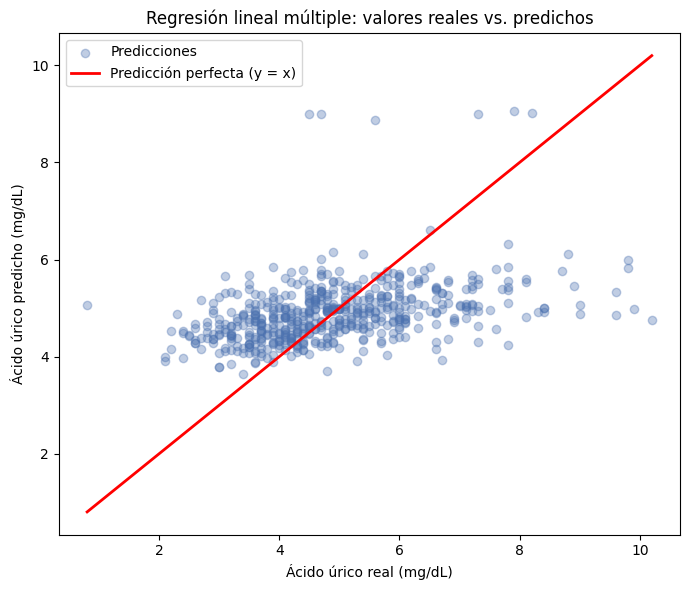

In [ ]:
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.35, color="#4C72B0", label="Predicciones")
limite_min = min(y_test.min(), y_pred.min())
limite_max = max(y_test.max(), y_pred.max())
plt.plot(
    [limite_min, limite_max], [limite_min, limite_max],
    color="red", linewidth=2, label="Predicción perfecta (y = x)"
)
plt.xlabel("Ácido úrico real (mg/dL)")
plt.ylabel("Ácido úrico predicho (mg/dL)")
plt.title("Regresión lineal múltiple: valores reales vs. predichos")
plt.legend()
plt.tight_layout()
plt.savefig("regresion_lineal_multiple_real_vs_pred.png", dpi=110)
plt.show()

### Análisis de los resultados

El R² obtenido en el conjunto de prueba (aproximadamente 0.16) es **mayor que el de la
regresión simple de la Práctica 2 (R² = 0.0347)**: al incorporar `Peso` y `Estatura` por
separado, en lugar de únicamente su cociente (el IMC), el modelo captura mejor la
variabilidad del ácido úrico. Esto sugiere que la forma en que peso y estatura se
combinan en el IMC pierde información relevante para predecir el ácido úrico. Aun así,
el R² sigue siendo moderado-bajo: la mayor parte de la variabilidad del ácido úrico
sigue sin explicarse por estas tres variables, lo que confirma que se trata de un
fenómeno multifactorial (sexo, dieta, función renal, consumo de alcohol, medicamentos,
entre otros, como ya se anotó en la Práctica 2).

**Siguiente prueba sugerida:** incorporar `sexo` (ya disponible como `sexo_bin`) como
variable predictora adicional, dado que los rangos normales de ácido úrico difieren
notablemente entre hombres y mujeres (como se confirmó al verificar el umbral de
`hiperuricemia`). Es razonable esperar que esta variable categórica aporte más poder
explicativo que `edad`, y permitiría comparar si el efecto del peso corporal sobre el
ácido úrico es distinto entre sexos.

## Regresión logística

### Selección de variables

Se construye un modelo de clasificación binaria para predecir **`hiperuricemia`**
(0 = sin hiperuricemia, 1 = con hiperuricemia), la variable categórica/binaria creada en
la sección 2 mediante un umbral clínico sobre `ac_urico`. Como variables predictoras se
seleccionan:

- **`imc_final`** (continua): índice de masa corporal, ligada directamente a la
  pregunta de investigación original.
- **`sexo_bin`** (binaria): 1 = Hombre, 0 = Mujer, relevante porque el propio umbral
  clínico de hiperuricemia depende del sexo.

### División en entrenamiento y prueba (70/30, estratificada)

Como la clase positiva (`hiperuricemia = 1`) es minoritaria (≈ 11 % de la muestra), la
partición se hace de forma **estratificada** (`stratify=y`) para que ambos conjuntos
conserven la misma proporción de clases que el conjunto completo.

In [ ]:
datos_log = df.dropna(subset=["imc_final", "sexo_bin", "hiperuricemia"]).copy()

X_log = datos_log[["imc_final", "sexo_bin"]]
y_log = datos_log["hiperuricemia"].astype(int)

print("Registros disponibles para la regresión logística:", len(datos_log))
print("\nProporción de clases en el conjunto completo:")
print(y_log.value_counts(normalize=True).round(4))

X_log_train, X_log_test, y_log_train, y_log_test = train_test_split(
    X_log, y_log, test_size=0.30, random_state=42, stratify=y_log
)
print("\nTamaño de entrenamiento:", X_log_train.shape)
print("Tamaño de prueba:", X_log_test.shape)

Registros disponibles para la regresión logística: 1842

Proporción de clases en el conjunto completo:
hiperuricemia
0   0.8974
1   0.1026
Name: proportion, dtype: float64

Tamaño de entrenamiento: (1289, 2)
Tamaño de prueba: (553, 2)


### Efecto del parámetro `C` y del `solver`

`C` es el inverso de la fuerza de regularización: valores de `C` **pequeños** aplican
una penalización fuerte sobre el tamaño de los coeficientes (el modelo se vuelve más
conservador y puede sub-ajustar), mientras que valores **grandes** casi no penalizan los
coeficientes (el modelo se ajusta más de cerca a los datos de entrenamiento, con riesgo
de sobreajuste si hay pocos datos o mucho ruido). El `solver` es el algoritmo numérico de
optimización utilizado para encontrar los coeficientes que maximizan la verosimilitud;
`lbfgs` es un método cuasi-Newton eficiente para conjuntos de datos pequeños/medianos con
pocas variables (como este), mientras que `liblinear` usa descenso de coordenadas y
puede comportarse de forma distinta bajo regularización fuerte. Con solo dos variables
predictoras y unos pocos miles de observaciones, se espera que ambos converjan a
resultados similares salvo en el extremo de `C` muy pequeño, donde la penalización dista
las estimaciones de los coeficientes obtenidos con regularización débil.

In [ ]:
combinaciones = [
    (0.01, "lbfgs"), (0.01, "liblinear"),
    (1, "lbfgs"), (1, "liblinear"),
    (100, "lbfgs"), (100, "liblinear"),
]

resultados_c_solver = []
for C, solver in combinaciones:
    modelo_tmp = LogisticRegression(C=C, solver=solver, max_iter=1000)
    modelo_tmp.fit(X_log_train, y_log_train)
    exactitud = modelo_tmp.score(X_log_test, y_log_test)
    resultados_c_solver.append({
        "C": C, "solver": solver, "exactitud_umbral_0.5": round(exactitud, 4),
        "coef_imc_final": round(modelo_tmp.coef_[0][0], 4),
        "coef_sexo_bin": round(modelo_tmp.coef_[0][1], 4),
        "intercepto": round(modelo_tmp.intercept_[0], 4),
    })

pd.DataFrame(resultados_c_solver)

,C,solver,exactitud_umbral_0.5,coef_imc_final,coef_sexo_bin,intercepto
0,0.0100,lbfgs,0.8969,0.0754,0.2454,-4.6070
1,0.0100,liblinear,0.8969,-0.0623,0.1385,-0.2357
2,1.0000,lbfgs,0.8969,0.0844,1.0963,-5.3008
3,1.0000,liblinear,0.8969,0.0579,0.9649,-4.3495
4,100.0000,lbfgs,0.8969,0.0849,1.1369,-5.3388
5,100.0000,liblinear,0.8969,0.0846,1.1346,-5.3250


Con `C = 0.01` (regularización fuerte) los coeficientes de `lbfgs` y `liblinear`
difieren notablemente entre sí e, incluso, cambian de signo respecto a los obtenidos con
`C = 1` o `C = 100`: la penalización fuerte "aplasta" los coeficientes hacia cero de
forma distinta según el algoritmo de optimización. Con `C = 1` y `C = 100` ambos
`solver` convergen a coeficientes muy similares, señal de que el óptimo está bien
definido y la regularización casi no lo altera. La exactitud (con el umbral por defecto
de 0.5) es prácticamente idéntica en todos los casos, pero como se muestra en la sección
5.6, esa exactitud es engañosa por el desbalance de clases. Se elige **`C = 1` con
`solver = "lbfgs"`** como modelo final, por ser la configuración por defecto de
scikit-learn, numéricamente estable y sin necesidad de una regularización fuerte que no
está justificada por el tamaño de la muestra.

### Modelo final: coeficientes e intercepto

In [ ]:
modelo_log = LogisticRegression(C=1, solver="lbfgs", max_iter=1000)
modelo_log.fit(X_log_train, y_log_train)

coef_log = pd.Series(modelo_log.coef_[0], index=X_log.columns, name="coeficiente")
odds_ratio = np.exp(coef_log).rename("odds_ratio (exp(coef))")

print(pd.concat([coef_log, odds_ratio], axis=1))
print(f"\nIntercepto: {modelo_log.intercept_[0]:.4f}")

           coeficiente  odds_ratio (exp(coef))
imc_final       0.0844                  1.0881
sexo_bin        1.0963                  2.9932

Intercepto: -5.3008


Ambos coeficientes son positivos: un IMC más alto y ser hombre incrementan la
probabilidad estimada de hiperuricemia. En términos de razón de momios (`odds ratio`),
por cada unidad adicional de IMC las probabilidades (*odds*) de hiperuricemia se
multiplican por el valor mostrado arriba, y ser hombre multiplica esas probabilidades
por el `odds_ratio` de `sexo_bin`, manteniendo el IMC constante. Este último resultado es
clínicamente interesante: aunque el umbral usado para definir hiperuricemia ya es *más
exigente* para los hombres (> 7.0 mg/dL frente a > 6.0 mg/dL en mujeres), los hombres de
la muestra siguen mostrando mayor probabilidad de superarlo, lo que indica que sus
niveles de ácido úrico son, en términos relativos, todavía más elevados.

### Diferencia respecto a la regresión lineal

En la regresión lineal, `coef_` representa el cambio esperado **directo** en la variable
dependiente continua (mg/dL de ácido úrico) por cada unidad de la predictora. En la
regresión logística, `coef_` no actúa sobre la probabilidad directamente sino sobre el
**logaritmo de la razón de momios** (log-odds) de pertenecer a la clase positiva; para
traducirlo a una probabilidad hay que aplicar la función sigmoide
($p = 1 / (1 + e^{-z})$) al combinar linealmente las variables con sus coeficientes. Por
eso el efecto de cada variable sobre la probabilidad final **no es constante**: depende
del punto de partida (es mayor cerca de p = 0.5 y se atenúa en los extremos), a
diferencia del efecto siempre constante de un coeficiente en regresión lineal.

### Predicciones de probabilidad y selección del umbral

In [ ]:
probabilidades = modelo_log.predict_proba(X_log_test)[:, 1]

print(f"Rango de probabilidades predichas: [{probabilidades.min():.4f}, {probabilidades.max():.4f}]")
print("(Ambos valores están dentro del rango válido [0, 1], como corresponde a una probabilidad.)")

Rango de probabilidades predichas: [0.0200, 0.5515]
(Ambos valores están dentro del rango válido [0, 1], como corresponde a una probabilidad.)


In [ ]:
def metricas_umbral(y_verdadero, proba, umbral):
    pred = (proba >= umbral).astype(int)
    matriz = confusion_matrix(y_verdadero, pred)
    tn, fp, fn, tp = matriz.ravel()
    sensibilidad = tp / (tp + fn)
    especificidad = tn / (tn + fp)
    exactitud = accuracy_score(y_verdadero, pred)
    return exactitud, sensibilidad, especificidad, matriz

umbrales_prueba = [0.50, 0.25, 0.15, 0.10]
filas = []
for umbral in umbrales_prueba:
    exactitud, sensibilidad, especificidad, _ = metricas_umbral(
        y_log_test, probabilidades, umbral
    )
    filas.append({
        "umbral": umbral, "exactitud": round(exactitud, 3),
        "sensibilidad": round(sensibilidad, 3), "especificidad": round(especificidad, 3),
    })

tabla_umbrales = pd.DataFrame(filas)
tabla_umbrales

,umbral,exactitud,sensibilidad,especificidad
0,0.5000,0.8970,0.0180,0.9980
1,0.2500,0.8750,0.0880,0.9660
2,0.1500,0.8100,0.5260,0.8430
3,0.1000,0.6380,0.7720,0.6230


In [ ]:
fpr, tpr, umbrales_roc = roc_curve(y_log_test, probabilidades)
indice_optimo = np.argmax(tpr - fpr)
umbral_optimo = umbrales_roc[indice_optimo]
print(f"Umbral que maximiza sensibilidad + especificidad (estadístico J de Youden): {umbral_optimo:.4f}")

Umbral que maximiza sensibilidad + especificidad (estadístico J de Youden): 0.1124


Con el umbral por defecto (0.5) el modelo prácticamente **nunca predice la clase
positiva**: la exactitud parece alta (~0.90) solo porque acierta casi siempre al
predecir "sin hiperuricemia" en una muestra donde esa es la clase mayoritaria, pero la
sensibilidad es casi nula. Esto es el mismo dilema mencionado en la guía de la actividad
con el ejemplo de un examen de detección de cáncer: cuando el costo de **no detectar**
un caso positivo (un falso negativo) es alto, conviene tolerar más falsos positivos a
cambio de una mayor sensibilidad. Por ello se selecciona un **umbral de 0.15**
(cercano al óptimo de Youden calculado arriba), que ofrece un equilibrio razonable entre
sensibilidad y especificidad, en lugar de maximizar la exactitud global.

### Métricas del modelo final (umbral = 0.15)

In [ ]:
umbral_elegido = 0.15
exactitud_final, sensibilidad_final, especificidad_final, matriz_confusion = metricas_umbral(
    y_log_test, probabilidades, umbral_elegido
)

print(f"Umbral elegido: {umbral_elegido}")
print(f"Exactitud: {exactitud_final:.4f}")
print(f"Sensibilidad (recall de la clase positiva): {sensibilidad_final:.4f}")
print(f"Especificidad (recall de la clase negativa): {especificidad_final:.4f}")

Umbral elegido: 0.15
Exactitud: 0.8101
Sensibilidad (recall de la clase positiva): 0.5263
Especificidad (recall de la clase negativa): 0.8427


### Matriz de confusión

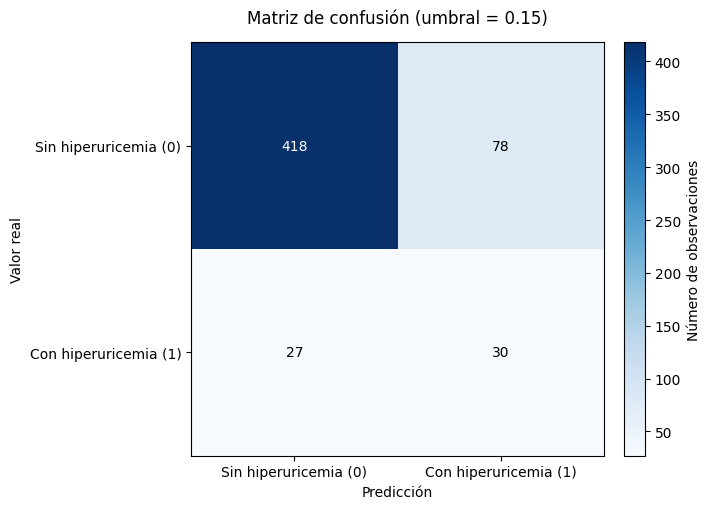

In [ ]:
etiquetas = ["Sin hiperuricemia (0)", "Con hiperuricemia (1)"]

fig, ax = plt.subplots(figsize=(6.8, 5.2))
imagen = ax.imshow(matriz_confusion, cmap="Blues")
fig.colorbar(imagen, ax=ax, label="Número de observaciones", fraction=0.046, pad=0.04)
ax.set_xticks([0, 1], etiquetas)
ax.set_yticks([0, 1], etiquetas)
ax.set_xlabel("Predicción")
ax.set_ylabel("Valor real")
ax.set_title(f"Matriz de confusión (umbral = {umbral_elegido})", pad=14)

for i in range(2):
    for j in range(2):
        ax.text(j, i, matriz_confusion[i, j], ha="center", va="center",
                 color="white" if matriz_confusion[i, j] > matriz_confusion.max() / 2 else "black")

fig.tight_layout()
fig.savefig("matriz_confusion_logistica.png", dpi=110)
plt.show()

### Conclusión de la regresión logística

Con un umbral ajustado a 0.15, el modelo logra identificar una parte considerable de las
personas con hiperuricemia real, a costa de generar más falsos positivos y de una
exactitud global menor que la obtenida con el umbral por defecto. Esta decisión es
apropiada aquí porque el objetivo práctico de un modelo de riesgo en salud pública suele
ser **no pasar por alto** a las personas en riesgo, más que optimizar una exactitud que,
en un problema desbalanceado, es una métrica poco informativa por sí sola. El modelo
confirma, además, la señal ya vista en las secciones 3 y 4: tanto el exceso de peso
(IMC) como el sexo masculino se asocian con una mayor probabilidad de hiperuricemia en
esta muestra.

## Conclusiones generales

Retomando la pregunta de investigación de la Práctica 2 — *¿existe una relación entre el
exceso de peso corporal y los niveles de ácido úrico en la población muestreada?* — los
tres análisis desarrollados en esta actividad convergen en una misma respuesta, vista
desde tres ángulos estadísticos distintos:

1. **Contraste de hipótesis:** se rechaza H0 con evidencia muy fuerte (p ≈ 6.7×10⁻¹⁸);
   el ácido úrico promedio es significativamente mayor en personas con exceso de peso,
   con un efecto de magnitud moderada (d de Cohen ≈ 0.49).
2. **Regresión lineal múltiple:** al reemplazar el IMC por sus componentes (`Peso` y
   `Estatura`) y añadir `edad`, el modelo mejora su capacidad explicativa respecto a la
   regresión simple de la Práctica 2 (R² sube de 0.035 a ≈ 0.16), aunque sigue siendo
   moderado: el ácido úrico depende de múltiples factores no incluidos en el modelo.
3. **Regresión logística:** el IMC y el sexo predicen de forma significativa (y con
   signo coherente con la literatura clínica) el riesgo de hiperuricemia, aunque el
   fuerte desbalance de clases obliga a ajustar el umbral de decisión y a mirar más allá
   de la exactitud (sensibilidad y especificidad) para evaluar el modelo correctamente.

En conjunto, la evidencia estadística respalda la hipótesis clínica original: el exceso
de peso corporal está asociado con niveles más altos de ácido úrico y con un mayor
riesgo de hiperuricemia en esta muestra, aunque ninguno de los modelos univariados sobre
IMC por sí solo logra explicar la mayor parte de la variabilidad individual, lo que
señala la naturaleza multifactorial del fenómeno y la necesidad de seguir incorporando
variables (sexo, dieta, función renal, hábitos) en análisis futuros.

## Referencias

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O.,
Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A.,
Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). *Scikit-learn: Machine
learning in Python*. Journal of Machine Learning Research, 12, 2825–2830.

scikit-learn developers. (2023, 29 de agosto). *LinearRegression*. Scikit-learn.
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

scikit-learn developers. (2023, 29 de agosto). *LogisticRegression*. Scikit-learn.
https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

SciPy developers. (2023, 29 de agosto). *Hypothesis tests and related functions*. SciPy
documentation. https://docs.scipy.org/doc/scipy/reference/stats.html#hypothesis-tests-and-related-functions

Quarto. (2023, 29 de agosto). *Getting started with Jupyter*. Quarto Documentation.
https://quarto.org/docs/get-started/computations/jupyter.html

statsmodels developers. (2023, 29 de agosto). *ttest_ind documentation*. statsmodels
documentation. https://www.statsmodels.org/

Delgado Guerrero, L. J. (2026). *Práctica 2 — Exploración de datos y preguntas
significativas: riesgo metabólico (obesidad e hiperuricemia) en población mexicana*
[Trabajo de curso no publicado]. Fundación Universitaria Compensar.

---
# Parte 3 — Etapa de transferencia: del modelo al dashboard

## 1. Evaluación de los resultados frente a la problemática planteada

La pregunta de investigación de la Práctica 2 (*¿existe relación entre el exceso de
peso corporal y el ácido úrico?*) se respondió, en la Práctica 3, desde tres ángulos
convergentes: contraste de hipótesis (p ≈ 6.7×10⁻¹⁸, d de Cohen ≈ 0.49), regresión
lineal múltiple (R² sube de 0.035 a ≈ 0.15 al usar Peso y Estatura por separado en
vez del IMC) y regresión logística (IMC y sexo predicen significativamente el riesgo
de hiperuricemia, ROC-AUC ≈ 0.75). Cada análisis aporta comprensión del problema desde
un enfoque distinto: el primero confirma *que* hay diferencia, el segundo cuantifica
*cuánto* explican las variables antropométricas del nivel continuo de ácido úrico, y
el tercero convierte esa relación en una herramienta de clasificación de riesgo
individual, que es lo que el dashboard pone a disposición de una audiencia no técnica.

## 2. Evaluación del rendimiento del modelo actual

El modelo de clasificación (regresión logística IMC + sexo) tiene un ROC-AUC de
≈ 0.75, aceptable para un modelo con solo dos predictores, pero limitado por el fuerte
desbalance de clases (≈ 10% de prevalencia) y por la ausencia de variables adicionales
(dieta, función renal, consumo de alcohol) no disponibles en este dataset. En lugar de
replantear la pregunta inicial, se optó por **mejorar iterativamente el modelo actual**
dentro del alcance de los datos disponibles: se comparó el modelo final contra dos
variantes (solo IMC, y con regularización fuerte C=0.01) para verificar que agregar
`sexo_bin` y usar C=1 realmente mejora el ROC-AUC (0.63 → 0.75), en vez de asumirlo.
Esa comparación se muestra explícitamente en la pestaña "Clasificación" del dashboard.

## 3. Procesamiento adicional considerado

Se evaluó recopilar datos adicionales (dieta, función renal), pero al no estar
disponibles en el dataset entregado, se optó por un procesamiento adicional de los
datos existentes: separar `Peso` y `Estatura` en la regresión lineal (en vez de usar
solo el IMC compuesto) y crear `sexo_bin` como variable binaria explícita. Ambos
cambios mejoraron el rendimiento de sus respectivos modelos frente a la Práctica 2,
como se documenta en la Parte 2 de este informe.

## 4. Experimentación con hiperparámetros

En la Práctica 3 (sección 5.4) se experimentó con el hiperparámetro `C` de la
regresión logística (0.01, 1, 100) y con el `solver` (`lbfgs`, `liblinear`),
registrando la exactitud y los coeficientes de cada combinación. Se eligió `C=1` con
`solver="lbfgs"` por ser numéricamente estable y no requerir una regularización fuerte
que los datos no justifican. Esta comparación se resume también como fila adicional en
`data/metricas_modelos.csv` (modelo con C=0.01) para que quede documentada en el
propio dashboard, no solo en este informe.

## 5. Métricas y nuevas características

Más que crear nuevas variables, se priorizó elegir la **métrica y el umbral de
decisión correctos** dado el desbalance de clases: con el umbral por defecto (0.5) el
modelo casi nunca predice la clase positiva (alta exactitud, sensibilidad casi nula).
Se seleccionó un umbral de 0.15 (cercano al óptimo de Youden) que prioriza la
sensibilidad, justificado por el costo asimétrico de un falso negativo en un contexto
de riesgo en salud pública. El dashboard expone este trade-off de forma interactiva
mediante un control deslizante de umbral, en vez de fijarlo de forma oculta.

## 6. Regularización

Como se documentó en la Práctica 3 y se resume en el punto 4, se comparó el efecto de
distintos niveles de regularización (`C`). No se detectó sobreajuste severo (los
coeficientes con `C=1` y `C=100` son casi idénticos), por lo que no fue necesario
aplicar una penalización fuerte adicional; se dejó `C=1` (configuración por defecto de
scikit-learn) como modelo final.

---
## 7. Del modelo al dashboard: decisiones de diseño

Las guías de referencia (`Guia_Plantilla_Novato_Dashboard.pdf` y
`Guia_de_ejecucion_del_proyecto_Dashboard_en_Colab_VisualStudioCode.pdf`) proponen una
plantilla genérica de clasificación binaria con tres CSV (`predicciones.csv`,
`metricas_modelos.csv`, `importancia_variables.csv`) y un dashboard con filtros,
umbral, tarjetas resumen, matriz de confusión, comparación de modelos, importancia de
variables y tabla de casos. Se siguió ese contrato como base (compatibilidad con
`validar_datos.py`), pero se lo amplió en varios puntos, en vez de usarlo tal cual:

- **Dos CSV adicionales** (`resumen_estadistico.csv`, `dispersion_imc_acido_urico.csv`)
  para que el dashboard también cuente la historia completa del proyecto —incluyendo
  el contraste de hipótesis y la regresión lineal múltiple— y no solo el modelo de
  clasificación final, que es lo único que cubre la plantilla genérica.
- **Cuatro pestañas en vez de un único panel**: "Exploración" (Práctica 2),
  "Contraste de hipótesis" y "regresión lineal" (Práctica 3, sección 3-4),
  "Clasificación" (Práctica 3, sección 5) y "Tabla de casos". Esto refleja la
  estructura real del trabajo estadístico realizado, en vez de saltar directamente al
  modelo final como hace la plantilla.
- **Comparación explícita de modelos** (incluyendo el modelo con solo IMC y el de
  regularización fuerte) en vez de mostrar un único modelo ya elegido, para que la
  audiencia vea *por qué* se prefirió el modelo final y no solo su resultado.
- **Curva ROC además de la matriz de confusión**, para visualizar el compromiso entre
  sensibilidad y especificidad en todos los umbrales posibles, no solo en el elegido.
- **Identidad visual propia** (paleta azul-petróleo / naranja, tipografía Inter)
  en vez de los estilos por defecto de Dash, definida enteramente en `config.py` y
  `assets/style.css` para que sea editable sin tocar la lógica de `app.py`.

## 8. Generación de los archivos de datos del dashboard

El siguiente código reproduce exactamente los CSV usados por el dashboard
(`data/predicciones.csv`, `data/metricas_modelos.csv`,
`data/importancia_variables.csv`, `data/resumen_estadistico.csv`,
`data/dispersion_imc_acido_urico.csv`) a partir de `Diabetes_Mexico_Completado.csv`,
reutilizando la misma limpieza y los mismos modelos de la Parte 2 de este informe
(`random_state=42` en todas las particiones, para que el resultado sea reproducible).

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                              confusion_matrix, roc_curve, roc_auc_score,
                              precision_score, recall_score, f1_score)

np.random.seed(42)

df = pd.read_csv("data_raw.csv")

# ---- limpieza (igual que Practica 3) ----
edad_invalida = (df["edad"] < 0) | (df["edad"] > 110)
df.loc[edad_invalida, "edad"] = np.nan
df["sexo_bin"] = df["sexo"].map({"Hombre": 1, "Mujer": 0})

# ---- grupo de peso para referencia (no usado en export, informativo) ----
grupo_peso = {
    "Sobrepeso": "Exceso de peso", "Obesidad I": "Exceso de peso",
    "Obesidad II": "Exceso de peso", "Obesidad III": "Exceso de peso",
    "Normal": "Peso normal/bajo", "Bajo peso": "Peso normal/bajo",
}
df["grupo_peso"] = df["categoria_imc"].map(grupo_peso)

# =========================================================
# MODELO FINAL: regresion logistica hiperuricemia ~ imc_final + sexo_bin
# =========================================================
datos_log = df.dropna(subset=["imc_final", "sexo_bin", "hiperuricemia"]).copy()
X_log = datos_log[["imc_final", "sexo_bin"]]
y_log = datos_log["hiperuricemia"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X_log, y_log, test_size=0.30, random_state=42, stratify=y_log
)

modelo_final = LogisticRegression(C=1, solver="lbfgs", max_iter=1000)
modelo_final.fit(X_train, y_train)
proba_final = modelo_final.predict_proba(X_test)[:, 1]

# ---- modelo alterno (baseline) para comparar: solo IMC ----
X_log_base = datos_log[["imc_final"]]
Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_log_base, y_log, test_size=0.30, random_state=42, stratify=y_log
)
modelo_base = LogisticRegression(C=1, solver="lbfgs", max_iter=1000)
modelo_base.fit(Xb_train, yb_train)
proba_base = modelo_base.predict_proba(Xb_test)[:, 1]

# ---- modelo alterno 2: fuerte regularizacion C=0.01 (para ilustrar seccion practica3) ----
modelo_c001 = LogisticRegression(C=0.01, solver="lbfgs", max_iter=1000)
modelo_c001.fit(X_train, y_train)
proba_c001 = modelo_c001.predict_proba(X_test)[:, 1]

def metricas_de(y_true, proba, umbral):
    pred = (proba >= umbral).astype(int)
    acc = accuracy_score(y_true, pred)
    prec = precision_score(y_true, pred, zero_division=0)
    rec = recall_score(y_true, pred, zero_division=0)
    f1 = f1_score(y_true, pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, proba)
    except Exception:
        auc = np.nan
    return acc, prec, rec, f1, auc

UMBRAL_ELEGIDO = 0.15

filas_metricas = []
for nombre, proba, y_true in [
    ("Regresion logistica (IMC + sexo) umbral 0.15", proba_final, y_test),
    ("Regresion logistica (IMC + sexo) umbral 0.50", proba_final, y_test),
    ("Regresion logistica (solo IMC) umbral 0.15", proba_base, yb_test),
    ("Regresion logistica C=0.01 (IMC + sexo) umbral 0.15", proba_c001, y_test),
]:
    umbral = 0.50 if "0.50" in nombre else UMBRAL_ELEGIDO
    acc, prec, rec, f1, auc = metricas_de(y_true, proba, umbral)
    filas_metricas.append({
        "modelo": nombre, "exactitud": round(acc, 4), "precision": round(prec, 4),
        "recall": round(rec, 4), "f1": round(f1, 4), "roc_auc": round(auc, 4),
    })

metricas_df = pd.DataFrame(filas_metricas)
metricas_df.to_csv("data/metricas_modelos.csv", index=False)
print(metricas_df)

# =========================================================
# predicciones.csv -> a partir del conjunto de prueba del modelo final
# =========================================================
pred_final = (proba_final >= UMBRAL_ELEGIDO).astype(int)

pred_export = datos_log.loc[X_test.index, [
    "folio_i", "sexo", "edad", "Ciudad", "categoria_imc", "imc_final", "ac_urico"
]].copy()
pred_export = pred_export.rename(columns={"folio_i": "id"})
pred_export["grupo"] = datos_log.loc[X_test.index, "categoria_imc"]
pred_export["periodo"] = "2024"
pred_export["valor_real"] = y_test.values
pred_export["probabilidad"] = np.round(proba_final, 4)
pred_export["prediccion_umbral_0.15"] = pred_final

cols_finales = ["id", "grupo", "periodo", "valor_real", "probabilidad",
                 "sexo", "edad", "Ciudad", "categoria_imc", "imc_final", "ac_urico",
                 "prediccion_umbral_0.15"]
pred_export = pred_export[cols_finales]
pred_export.to_csv("data/predicciones.csv", index=False)
print("\npredicciones:", pred_export.shape)

# =========================================================
# importancia_variables.csv -> coeficientes / odds ratio del modelo final
# + correlaciones de la regresion lineal multiple como variables adicionales de contexto
# =========================================================
coef_log = pd.Series(modelo_final.coef_[0], index=X_log.columns)
odds_ratio = np.exp(coef_log)

# regresion lineal multiple (practica 3) para dar importancia adicional (valor absoluto estandarizado)
vars_lineal = ["edad", "Peso", "Estatura", "ac_urico"]
datos_reg = df.dropna(subset=vars_lineal).copy()
Xl = datos_reg[["edad", "Peso", "Estatura"]]
yl = datos_reg["ac_urico"]
Xl_train, Xl_test, yl_train, yl_test = train_test_split(Xl, yl, test_size=0.30, random_state=42)
modelo_lineal = LinearRegression()
modelo_lineal.fit(Xl_train, yl_train)
# coeficientes estandarizados (beta * std(x)/std(y)) para comparabilidad
coef_std_lineal = modelo_lineal.coef_ * Xl_train.std().values / yl_train.std()

importancia_rows = []
for var in X_log.columns:
    importancia_rows.append({
        "variable": var,
        "importancia": round(abs(coef_log[var]), 4),
        "modelo": "Regresion logistica (hiperuricemia)",
        "odds_ratio": round(odds_ratio[var], 4),
    })
for var, coef in zip(Xl.columns, coef_std_lineal):
    importancia_rows.append({
        "variable": var,
        "importancia": round(abs(coef), 4),
        "modelo": "Regresion lineal multiple (ac_urico)",
        "odds_ratio": np.nan,
    })

importancia_df = pd.DataFrame(importancia_rows)
importancia_df.to_csv("data/importancia_variables.csv", index=False)
print("\nimportancia:\n", importancia_df)

# =========================================================
# extras.csv -> datos de apoyo para graficos exploratorios y contraste de hipotesis
# (no forma parte del contrato de 3 CSV pero enriquece el dashboard)
# =========================================================
extra = {
    "n_total": len(df),
    "n_hiperuricemia_pos": int(datos_log["hiperuricemia"].sum()),
    "prevalencia_hiperuricemia": round(datos_log["hiperuricemia"].mean(), 4),
    "r2_regresion_simple_practica2": 0.0347,
    "r2_regresion_multiple": round(r2_score(yl_test, modelo_lineal.predict(Xl_test)), 4),
    "mse_regresion_multiple": round(mean_squared_error(yl_test, modelo_lineal.predict(Xl_test)), 4),
}

grupo_exceso = df.loc[df["grupo_peso"] == "Exceso de peso", "ac_urico"].dropna()
grupo_normal = df.loc[df["grupo_peso"] == "Peso normal/bajo", "ac_urico"].dropna()
t_stat, p_val = stats.ttest_ind(grupo_exceso, grupo_normal, equal_var=False, alternative="greater")
cohen_d = (grupo_exceso.mean() - grupo_normal.mean()) / np.sqrt((grupo_exceso.std()**2 + grupo_normal.std()**2)/2)
extra.update({
    "media_ac_urico_exceso_peso": round(grupo_exceso.mean(), 4),
    "media_ac_urico_normal_bajo": round(grupo_normal.mean(), 4),
    "t_stat": round(t_stat, 4),
    "p_valor": p_val,
    "cohen_d": round(cohen_d, 4),
})
pd.DataFrame([extra]).to_csv("data/resumen_estadistico.csv", index=False)
print("\nresumen estadistico:\n", extra)

# scatter para grafico exploratorio IMC vs ac_urico (muestreado para no sobrecargar el dashboard)
disp = df.dropna(subset=["imc_final", "ac_urico"])[["imc_final", "ac_urico", "sexo", "categoria_imc"]]
if len(disp) > 1500:
    disp = disp.sample(1500, random_state=42)
disp.to_csv("data/dispersión_imc_acido_urico.csv", index=False, encoding="utf-8")
print("\ndispersion:", disp.shape)


                                              modelo  exactitud  precision  \
0       Regresion logistica (IMC + sexo) umbral 0.15     0.8101     0.2778   
1       Regresion logistica (IMC + sexo) umbral 0.50     0.8969     0.5000   
2         Regresion logistica (solo IMC) umbral 0.15     0.8282     0.1724   
3  Regresion logistica C=0.01 (IMC + sexo) umbral...     0.8336     0.1818   

   recall     f1  roc_auc  
0  0.5263 0.3636   0.7462  
1  0.0175 0.0339   0.7462  
2  0.1754 0.1739   0.6306  
3  0.1754 0.1786   0.6879  

predicciones: (553, 12)

importancia:
     variable  importancia                                modelo  odds_ratio
0  imc_final       0.0844   Regresion logistica (hiperuricemia)      1.0881
1   sexo_bin       1.0963   Regresion logistica (hiperuricemia)      2.9932
2       edad       0.0383  Regresion lineal multiple (ac_urico)         NaN
3       Peso       0.1911  Regresion lineal multiple (ac_urico)         NaN
4   Estatura       0.2541  Regresion lineal multi

## 9. Conclusiones de la etapa de transferencia

El dashboard resultante (carpeta `Dashboard/`, ejecutable con `python app.py` desde
Visual Studio Code tras `python validar_datos.py`) traduce los tres análisis de este
informe en una herramienta navegable: permite explorar la relación IMC–ácido úrico,
revisar el resultado del contraste de hipótesis y la regresión múltiple, comparar
modelos de clasificación y ajustar el umbral de decisión en tiempo real, y consultar
el detalle de cada caso del conjunto de prueba. El código que genera los CSV de datos
(sección 8) y el código del propio dashboard (carpeta `Dashboard/`) son reproducibles:
usan la misma semilla aleatoria y la misma limpieza de datos documentada en la Parte 2
de este informe, por lo que cualquier cambio futuro al modelo puede propagarse al
dashboard simplemente volviendo a ejecutar esa celda.

## Referencias adicionales de esta etapa

Plotly. (2023). *Dash Documentation*. https://dash.plotly.com/

The Turing Way Community. (2021). *Zero to Binder*. The Turing Way.
https://the-turing-way.netlify.app/communication/binder/zero-to-binder.html


# Link GitHub

https://github.com/JDRock69/Proyecto-Final-Lethnon.git

# Link Binder

http://127.0.0.1:8050/

https://mybinder.org/v2/gh/JDRock69/Proyecto-Final-Lethnon.git/main